In [1]:
# tools
import pandas as pd
import numpy as np
from sqlalchemy import create_engine
from clear_date import batch_load_sql

# model
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

# clear date
from clear_date import clear_user_data, clear_post_data

# visual 
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

In [2]:
df_user_data = batch_load_sql(
    "SELECT * FROM user_data WHERE user_id >= 20000 and user_id <= 30000 LIMIT 10000"
)
df_post_data = batch_load_sql("SELECT * FROM post LIMIT 10000")

In [3]:
df_user_data

,user_id,gender,age,country,city,exp_group,os,source
0,20000,0,36,Russia,Vyazniki,1,Android,ads
1,20001,0,33,Russia,Barabinsk,0,iOS,ads
2,20002,0,15,Finland,Riihimäki,1,Android,ads
3,20003,0,53,Russia,Saint Petersburg,2,Android,ads
4,20004,1,45,Russia,Ufa,0,Android,ads
...,...,...,...,...,...,...,...,...
9986,29996,1,20,Russia,Khabarovsk,1,Android,ads
9987,29997,1,34,Russia,Blagoveshchensk,2,Android,ads
9988,29998,1,21,Russia,Arkhangelsk,0,Android,ads
9989,29999,1,17,Russia,Pskov,3,iOS,ads


In [4]:
df_post_data

,id,text,topic
0,1,UK economy facing major risks\n\nThe UK manufa...,business
1,2,Aids and climate top Davos agenda\n\nClimate c...,business
2,3,Asian quake hits European shares\n\nShares in ...,business
3,4,India power shares jump on debut\n\nShares in ...,business
4,5,Lacroix label bought by US firm\n\nLuxury good...,business
...,...,...,...
7018,7315,"OK, I would not normally watch a Farrelly brot...",movie
7019,7316,I give this movie 2 stars purely because of it...,movie
7020,7317,I cant believe this film was allowed to be mad...,movie
7021,7318,The version I saw of this film was the Blockbu...,movie


In [5]:
df_user_data_1 = clear_user_data(df_user_data)
df_post_data_1 = clear_post_data(df_post_data)

In [6]:
df = pd.concat([df_post_data_1.reset_index(drop=True),
                       df_user_data_1.reset_index(drop=True)], axis=1)


In [7]:
N = len(df)
noise = np.random.normal(loc=0.0, scale=20.0, size=N)
df['tfidf_sum_noisy'] = df['tfidf_sum'] + noise

z = np.cos(df['tfidf_sum_noisy']) * df['tfidf_sum_noisy'] \
    + 0.3 * df['age']
prob = 1 / (1 + np.exp(-z))

prob = np.nan_to_num(prob, nan=0.5)

df['target'] = np.random.binomial(1, prob)


In [8]:
df = df.dropna()
df

,tfidf_sum,topic_business,topic_covid,topic_entertainment,topic_movie,topic_politics,topic_sport,topic_tech,tfidf_sum_noisy,gender,...,city_İmişli,city_İnegöl,city_İsmayıllı,city_İzmir,city_Şanlıurfa,city_Şirvan,city_Əmircan,os_Android,os_iOS,target
0,10.593563,True,False,False,False,False,False,False,23.699874,0,...,False,False,False,False,False,False,False,True,False,1
1,13.535486,True,False,False,False,False,False,False,-11.544771,0,...,False,False,False,False,False,False,False,False,True,1
2,14.242152,True,False,False,False,False,False,False,31.785774,0,...,False,False,False,False,False,False,False,True,False,1
3,7.907119,True,False,False,False,False,False,False,-19.230188,0,...,False,False,False,False,False,False,False,True,False,0
4,7.711824,True,False,False,False,False,False,False,-15.265544,1,...,False,False,False,False,False,False,False,True,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7018,8.711871,False,False,False,True,False,False,False,-8.495873,0,...,False,False,False,False,False,False,False,False,True,1
7019,8.895322,False,False,False,True,False,False,False,5.226152,1,...,False,False,False,False,False,False,False,True,False,1
7020,7.295466,False,False,False,True,False,False,False,27.836405,0,...,False,False,False,False,False,False,False,True,False,0
7021,8.587642,False,False,False,True,False,False,False,-1.682706,0,...,False,False,False,False,False,False,False,True,False,1


In [9]:
df['target'].value_counts(normalize=True)

target
1    0.744269
0    0.255731
Name: proportion, dtype: float64

In [10]:
X = df.drop("target", axis=1)
X.to_csv("../date/X")

y = df["target"]

rf_pipe = Pipeline([
    ("scal", MinMaxScaler()),
    ("clf", RandomForestClassifier())
])

gb_pipe = Pipeline([
    ("scal", MinMaxScaler()),
    ("clf", GradientBoostingClassifier())
])

lr_pipe = Pipeline([
    ("scal", MinMaxScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y)

rf_pipe.fit(X_train, y_train)
gb_pipe.fit(X_train, y_train)
lr_pipe.fit(X_train, y_train)

Pipeline(steps=[('scal', MinMaxScaler()),
                ('clf', LogisticRegression(max_iter=1000))])

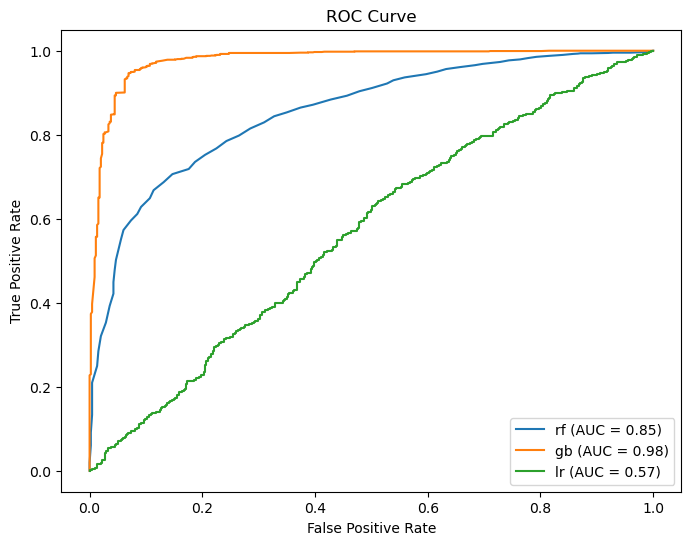

In [11]:
rf_probs = rf_pipe.predict_proba(X_test)[:, 1]
gb_probs = gb_pipe.predict_proba(X_test)[:, 1]
lr_probs = lr_pipe.predict_proba(X_test)[:, 1]

rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
gb_fpr, gb_tpr, _ = roc_curve(y_test, gb_probs)
lg_fpr, lg_tpr, _ = roc_curve(y_test, lr_probs)

plt.figure(figsize=(8,6))
plt.plot(rf_fpr, rf_tpr, label=f'rf (AUC = {roc_auc_score(y_test, rf_probs):.2f})')
plt.plot(gb_fpr, gb_tpr, label=f'gb (AUC = {roc_auc_score(y_test, gb_probs):.2f})')
plt.plot(lg_fpr, lg_tpr, label=f'lr (AUC = {roc_auc_score(y_test, lr_probs):.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()

# 🧪 test

In [12]:
def recommend_for_user(user_id: int, top_k: int = 5):
    u = df_user_data_1.loc[[user_id]]
    print(u.shape)
    p = df_post_data_1.reset_index()
    users_block = pd.concat([u]*len(p), ignore_index=True)
    X_cand = pd.concat([users_block.reset_index(drop=True), p.reset_index(drop=True)], axis=1)
    X_cand = X_cand[X.columns]
    rf_p = rf_pipe.predict_proba(X_cand)[:, 1]
    gb_p = gb_pipe.predict_proba(X_cand)[:, 1]
    lr_p = lr_pipe.predict_proba(X_cand)[:, 1]
    avg_p = (rf_p + gb_p + lr_p) / 3
    top_idx = np.argsort(avg_p)[::-1][:top_k]

    return list(zip(p.loc[top_idx, 'id'], avg_p[top_idx]))

    
user_id = 29566
recommendations = recommend_for_user(user_id)
for post_id, prob in recommendations:
    print(f"Post ID: {post_id}, Шанс: {prob:.5f}")

(1, 1605)
Post ID: 7011, Шанс: 0.93464
Post ID: 6452, Шанс: 0.93440
Post ID: 5929, Шанс: 0.93352
Post ID: 6138, Шанс: 0.93304
Post ID: 6622, Шанс: 0.93271


# 💾 save

In [13]:
import pickle

models = [rf_pipe, gb_pipe, lr_pipe]

def save_models(model_list):
    for idx, model in enumerate(model_list, start=1):
        with open(f"{idx}_model.pkl", "wb") as f:
            pickle.dump(model, f)

save_models(models)